## Building a Neural Network using Brian2 including FS, RS and IMP neurons.

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

In this notebook we build a neural network using Brian2 and including FS, RS and IMP neurons.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from utils.Brian_function_helper import *
from utils.Plots_helper import *

### Defining duration of the simulation

In [4]:
sim_duration = 30 * b2.second
dt = 0.1 * b2.ms  # time resolution
times = b2.arange(0, sim_duration, dt)

### Setting up the neuron models

In [5]:
data_folder = '../AdEx_models'
idx = 0 # in this case only one model per cell type is provided

#### Setting up holding current

In [6]:
# In case you don't want the current injected to be zero
# Comment the next three lines.
stim_t_start = 0
stim_t_end = int(sim_duration)
stim_amplitude = 0 * b2.nA

# Adding a "step of current" for testing
# Comment out next three lines if you like to inject a "step current".
#stim_t_start = 2   #seconds
#stim_t_end = 5     #seconds
#stim_amplitude = 0.35 * b2.nA

stim_unit = 1. * b2.ms
stim_time = sim_duration

# Setting up the step current injection protocol
tmp_size = 2 + stim_t_end  
tmp = np.zeros((tmp_size, 1)) * b2.amp
tmp[stim_t_start: stim_t_end + 1, 0] = stim_amplitude
curr_array = b2.TimedArray(tmp, dt=1. * stim_unit).values.flatten()  # to solve the issue with dimention of the current vector
current_timed_array = b2.TimedArray(curr_array * b2.amp, dt=stim_unit)

#### Defining the neuron models and number of neurons per population

In [7]:
neuron_model = 'FS_cr'
N_cell_FS = 10
G_inh = setting_simulation_Brian(idx = idx,
                                 N_cell = N_cell_FS,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                 curr_inj = current_timed_array)

neuron_model = 'RS_cr'
N_cell_RS = 10
G_exc = setting_simulation_Brian(idx = idx,
                                 N_cell = N_cell_RS,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                 curr_inj = current_timed_array)
neuron_model = 'IMP_cr'
N_cell_IMP = 10
G_imp = setting_simulation_Brian(idx = idx,
                                 N_cell = N_cell_IMP,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                 curr_inj = current_timed_array)


### Connecting the 3 populations

The neurons are connected through a random and sparse (Erdős-Rényi type) architecture.

In [8]:
conn_prob = 0.05 # connection probability

In [9]:
# Quantal increment in synaptic conductances:
Qe = 1.5 * b2.nS
Qi = 5.0 * b2.nS

In [10]:
# Creating synapses -> connecting the populations
# We assume that:
# pop_1 is the inhibitory population, 
# pop_2 the excitatory population,
# and pop_3 the impaired.
#'''
S_11, S_12, S_13, S_21, S_22, S_23, S_31, S_32, S_33 = network_creation(conn_prob = conn_prob,
                                                                         pop_1 = G_inh, 
                                                                         pop_2 = G_exc, 
                                                                         pop_3 = G_imp, 
                                                                         Qe = Qe, 
                                                                         Qi = Qi,
                                                                         seed = 1234)
#'''
# The function network_creation sets up all the connection.
# If you want to investigate the effect of a specific synapse,
# you can comment the previous interal synapse creation (i.e.you don't call the network_creation function)
# and use instead, for example:
'''
S_21 = b2.Synapses(G_exc, G_inh, on_pre='GsynE_post+=Qe', name = 'S_21') 
S_21.connect(p=conn_prob)
S_12 = b2.Synapses(G_inh, G_exc, on_pre='GsynI_post+=Qi', name = 'S_12')
S_12.connect(p=conn_prob)
'''

"\nS_21 = b2.Synapses(G_exc, G_inh, on_pre='GsynE_post+=Qe', name = 'S_21') \nS_21.connect(p=conn_prob)\nS_12 = b2.Synapses(G_inh, G_exc, on_pre='GsynI_post+=Qi', name = 'S_12')\nS_12.connect(p=conn_prob)\n"

In [11]:
int_syn = [S_11, S_12, S_13, S_21, S_22, S_23, S_31, S_32, S_33]
for syn in int_syn:
    print(syn.name, syn.source.name, '->', syn.target.name, f': {len(syn.i)} connections')

S_11 FS_cr -> FS_cr : 7 connections
S_12 FS_cr -> RS_cr : 5 connections
S_13 FS_cr -> IMP : 6 connections
S_21 RS_cr -> FS_cr : 2 connections
S_22 RS_cr -> RS_cr : 6 connections
S_23 RS_cr -> IMP : 3 connections
S_31 IMP -> FS_cr : 6 connections
S_32 IMP -> RS_cr : 5 connections
S_33 IMP -> IMP : 6 connections


### Defining the external drive/input

In [12]:
b2.seed(1234) # fixing seed for reproducibility 

N_external = 8000 # number of external neurons - number of incoming spikes
rate_external_input_all = 1 * b2.Hz # firing rate of the external input

P_ed_all = b2.PoissonGroup(N_external, rates=rate_external_input_all)


### Connecting the external input to the neuron models

In [13]:
# Synapses: all external neurons project to the FS, RS and IMP neurons
# S_ed -> synapses_external_drive

# Background input (All the cell types receive the same)
S_ed_background_inh = b2.Synapses(P_ed_all, G_inh, on_pre='GsynE_post+=Qe')
S_ed_background_inh.connect(p=conn_prob) 
S_ed_background_exc = b2.Synapses(P_ed_all, G_exc, on_pre='GsynE_post+=Qe')
S_ed_background_exc.connect(p=conn_prob) 
S_ed_background_imp = b2.Synapses(P_ed_all, G_imp, on_pre='GsynE_post+=Qe')
S_ed_background_imp.connect(p=conn_prob) 


### Defining the Monitors (variables to record)

In [14]:
#mon_FS = b2.StateMonitor(G_inh, ['v', 'Is'], record=True)
mon_spike_FS = b2.SpikeMonitor(G_inh)
mon_rate_FS = b2.PopulationRateMonitor(G_inh)

#mon_RS = b2.StateMonitor(G_exc, ['v', 'Is'], record=True)
mon_spike_RS = b2.SpikeMonitor(G_exc)
mon_rate_RS = b2.PopulationRateMonitor(G_exc)

#mon_IMP = b2.StateMonitor(G_imp, ['v', 'Is'], record=True)
mon_spike_IMP = b2.SpikeMonitor(G_imp)
mon_rate_IMP = b2.PopulationRateMonitor(G_imp)

mon_Poisson_input_all = b2.SpikeMonitor(P_ed_all)


In [15]:
# to explore what's in the Monitor, use:
# print(dir(mon_FS))
# or for more details
# help(mon_FS)

### Running the simulation of the neural network containing the 3 populations

In [16]:
%%time
b2.run(sim_duration, namespace={'current': current_timed_array,
                                'Qe': Qe,
                                'Qi': Qi})

CPU times: user 47.8 s, sys: 128 ms, total: 47.9 s
Wall time: 52.6 s


### Plotting the results

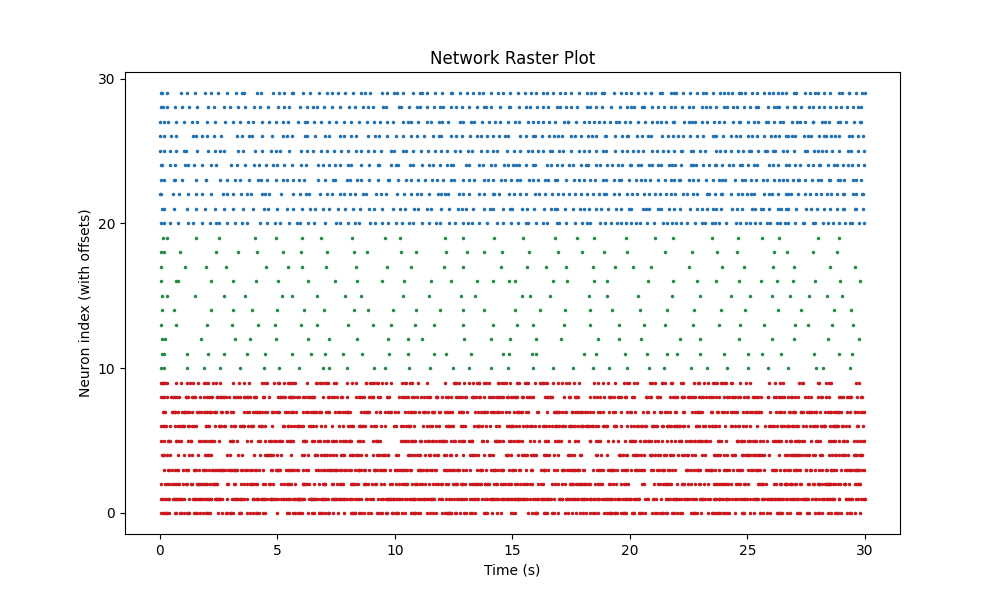

In [17]:
fig = network_raster_plot(pop1 = mon_spike_FS, 
                    pop2 = mon_spike_RS, 
                    pop3 = mon_spike_IMP,
                    N_pop1 = N_cell_FS,
                    N_pop2 = N_cell_RS,
                    N_pop3 = N_cell_IMP,
                    #marker = 'o',
                    markersize = 3)

INFO       width adjusted from 0.5 s to 0.5001 s [brian2.monitors.ratemonitor.adjusted_width]


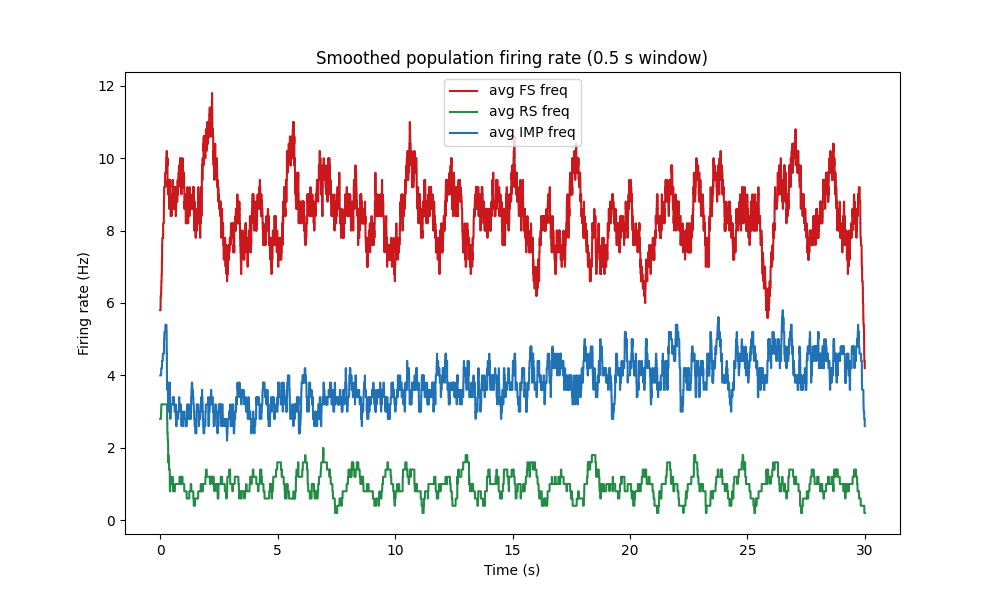

In [18]:
fig = plotting_pop_firing_rate(pop1 = mon_rate_FS, 
                    pop2 = mon_rate_RS, 
                    pop3 = mon_rate_IMP,
                    bin_window=500*b2.ms)

WARNING    /home/ilaria/.local/lib/python3.8/site-packages/brian2/units/fundamentalunits.py:1036: UserWarning: Unknown ufunc 'clip' in __array_prepare__
  warn("Unknown ufunc '%s' in __array_prepare__" % uf.__name__)
 [py.warnings]
WARNING    /home/ilaria/.local/lib/python3.8/site-packages/brian2/units/fundamentalunits.py:1071: UserWarning: Unknown ufunc 'clip' in __array_wrap__
  warn("Unknown ufunc '%s' in __array_wrap__" % uf.__name__)
 [py.warnings]


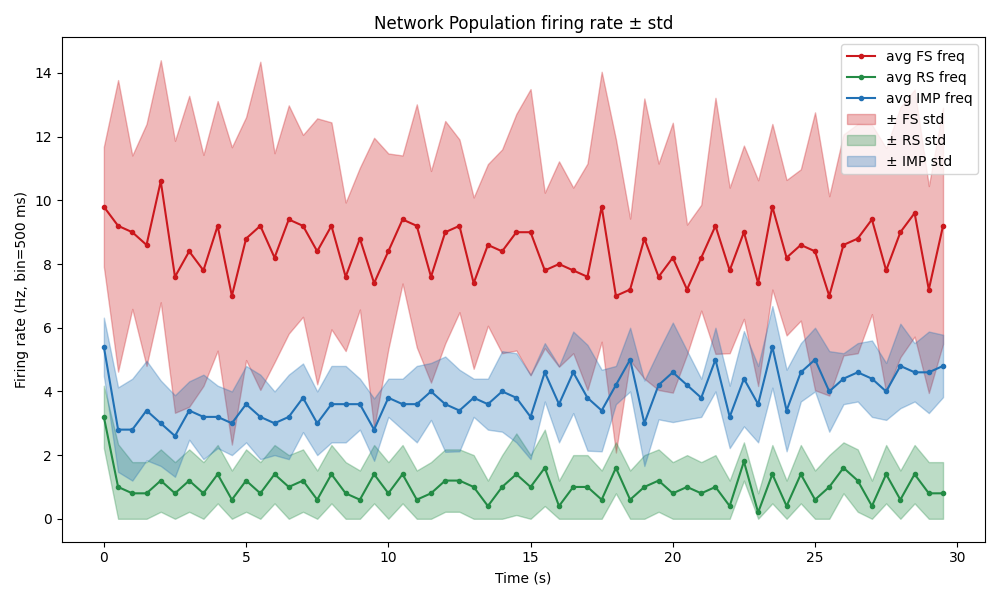

In [19]:
fig = plotting_pop_freq_and_std(sim_duration = sim_duration, 
                              pop1 = mon_spike_FS, 
                              pop2 = mon_spike_RS, 
                              pop3 = mon_spike_IMP,
                              N_pop1 = N_cell_FS,
                              N_pop2 = N_cell_RS,
                              N_pop3 = N_cell_IMP,
                              bin_size=500*b2.ms
                              )